<a href="https://colab.research.google.com/github/anushareddy-7/Customer-Ticket-Satisfaction/blob/main/Customer_Satisfaction_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Customer Satisfaction Prediction using Machine Learning**

In [57]:
#importing important Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [58]:
# Load the dataset
data=pd.read_csv('/content/customer_support_tickets.csv')

In [59]:
# Find the rows of a dataset
print(data.head())

   Ticket ID        Customer Name              Customer Email  Customer Age  \
0          1        Marisa Obrien  carrollallison@example.com            32   
1          2         Jessica Rios    clarkeashley@example.com            42   
2          3  Christopher Robbins   gonzalestracy@example.com            48   
3          4     Christina Dillon    bradleyolson@example.org            27   
4          5    Alexander Carroll     bradleymark@example.com            67   

  Customer Gender Product Purchased Date of Purchase      Ticket Type  \
0           Other        GoPro Hero       2021-03-22  Technical issue   
1          Female       LG Smart TV       2021-05-22  Technical issue   
2           Other          Dell XPS       2020-07-14  Technical issue   
3          Female  Microsoft Office       2020-11-13  Billing inquiry   
4          Female  Autodesk AutoCAD       2020-02-04  Billing inquiry   

             Ticket Subject  \
0             Product setup   
1  Peripheral compatibil

In [60]:
#Display basic info about the dataset
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

**Data** **Preprocessing**

In [61]:
# Find the missing values

data.isnull().sum()

,0
Ticket ID,0
Customer Name,0
Customer Email,0
Customer Age,0
Customer Gender,0
Product Purchased,0
Date of Purchase,0
Ticket Type,0
Ticket Subject,0
Ticket Description,0


In [62]:
# dropping null values
data.dropna(inplace=True)

In [63]:
#Rechecking null values after dropping
data.isnull().sum()

,0
Ticket ID,0
Customer Name,0
Customer Email,0
Customer Age,0
Customer Gender,0
Product Purchased,0
Date of Purchase,0
Ticket Type,0
Ticket Subject,0
Ticket Description,0


In [64]:
#Encoding Categorical variables

label_encoders={}
for column in data.select_dtypes(include=['object']).columns:
  label_encoders[column]=LabelEncoder()

  data[column]=label_encoders[column].fit_transform(data[column])


In [65]:
data.shape

(2769, 17)

In [66]:
#Define Features and target variable

data.columns
x=data.drop(['Ticket ID','Customer Name','Customer Email','Ticket Subject','Ticket Description','Customer Satisfaction Rating'],axis=1)
y=data['Customer Satisfaction Rating']


In [67]:
#splitting the dataset

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)
print(x_train)
print(x_test)
print(y_train)
print(y_test)

      Customer Age  Customer Gender  Product Purchased  Date of Purchase  \
3701            59                2                  7               258   
4993            39                1                  6               666   
7594            69                1                 39               689   
3359            35                0                  2               662   
4136            57                0                 25               104   
...            ...              ...                ...               ...   
5053            20                2                 17               249   
3362            26                1                 25               143   
3473            54                2                 35                82   
3950            52                2                 10               383   
2661            51                1                 26                36   

      Ticket Type  Ticket Status  Resolution  Ticket Priority  Ticket Channel  \
3701  

In [68]:
# Feature Scaling

scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)   #learn+transfrom
x_test=scaler.transform(x_test)         #only transform

In [69]:
#Model Building

rfc=RandomForestClassifier(random_state=42)
rfc=RandomForestClassifier(n_estimators=100,random_state=42)     #controls trees

#Train the model
rfc.fit(x_train,y_train)

#Predict on the test set
y_pred=rfc.predict(x_test)

In [70]:
# model Evalution
print("Accuracy:",accuracy_score(y_test,y_pred))                                # Accuracy Score
print("\nclassification Report:\n",classification_report(y_test,y_pred))       #classification Report
print("\nconfusion Matrix:\n",confusion_matrix(y_test,y_pred))                 #Confusion Matrix

Accuracy: 0.19133574007220217

classification Report:
               precision    recall  f1-score   support

         1.0       0.22      0.24      0.23       168
         2.0       0.19      0.17      0.18       174
         3.0       0.17      0.17      0.17       175
         4.0       0.20      0.19      0.19       162
         5.0       0.17      0.20      0.18       152

    accuracy                           0.19       831
   macro avg       0.19      0.19      0.19       831
weighted avg       0.19      0.19      0.19       831


confusion Matrix:
 [[40 37 33 27 31]
 [35 30 44 28 37]
 [43 35 29 30 38]
 [32 32 31 30 37]
 [33 24 33 32 30]]


In [71]:
#Feature Importance

feature_importances=pd.Series(rfc.feature_importances_, index=x.columns)
top10=feature_importances.sort_values(ascending=False).head(10)

print(top10)


Time to Resolution     0.138206
Date of Purchase       0.138150
First Response Time    0.138084
Resolution             0.137171
Customer Age           0.122553
Product Purchased      0.116584
Ticket Type            0.060029
Ticket Priority        0.055375
Ticket Channel         0.051893
Customer Gender        0.041956
dtype: float64


**Observation:**

Time to Resolution has the highest impact on satisfaction

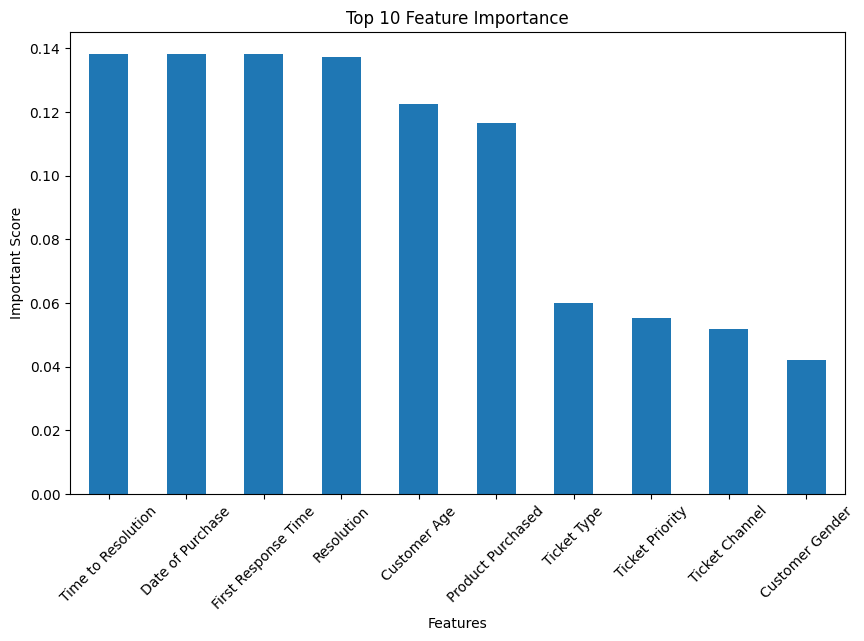

In [72]:
# Visualization of results

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
feature_importances.nlargest(10).plot(kind='bar')
plt.title('Top 10 Feature Importance')
plt.xlabel('Features')
plt.ylabel('Important Score')
plt.xticks(rotation=45)

plt.show()

**Observation :**

Resolution efficency significantly impacts customer satisfcation levels

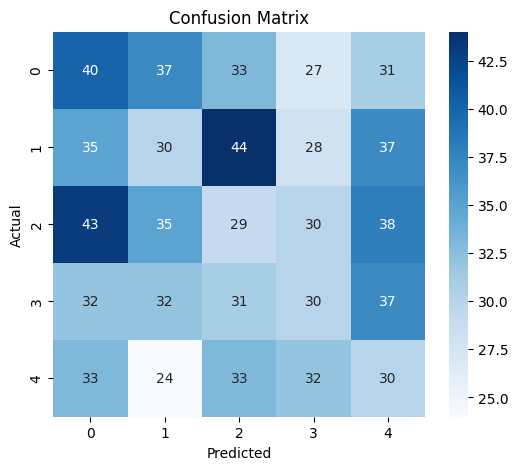

In [73]:
#Confusion Matrix
#This is shows correct predictions and wrong predictions

cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='.0f',cmap='Blues') #float number 0 digits after decimal(displays them like integer)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

**Observation: **

The Confusion matrix shows the performance of the RandomForestClassifer across 5 customer satisfaction classes(0-4)

1.The diagonal value represent correct predictions.

2.The diagonal values (40,30,29,30,30) are not significantly higher than other values in each row.

3.This indicates that the model struggles to clearly distinguish between differet satisfaction levels.

There is noticeable confusion between classes:
1.Class 1 is frequently predicted as class 2.
2.Class 2 is often misclassified  as class 0.

predictions are distributed across multiple classes rather than being concentrated on the correct class.

Overall the model shows moderate to low Classification performance,as misclassifications are relatively high compared to correct predictions.


In [74]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         1.0       0.22      0.24      0.23       168
         2.0       0.19      0.17      0.18       174
         3.0       0.17      0.17      0.17       175
         4.0       0.20      0.19      0.19       162
         5.0       0.17      0.20      0.18       152

    accuracy                           0.19       831
   macro avg       0.19      0.19      0.19       831
weighted avg       0.19      0.19      0.19       831



**Observation:**

1.Overall Accuracy:

Overall accuracy model is 19%
Since this is a 5-class classificaton problem, random guessing would give around 20% accuracy.
This means the model is performing close to random prediction.

2.Precision:

precision ranges between 0.17 and 0.22.
when the model predicts a satisfaction class, it is correctly only about 17-22% of the time.
The model does not confidently separate the classes.

3.Recall

Recall ranges between 0.17 and 0.24 of actual class instances.
many samples are classified.

4.F1-Scores

F1 Scores values are around 0.17-0.23

The balance between precision and recall is low.
Overall model performance is weak across  all classes.

5.Class Distribution:

support values are nearly equal:
168,174,175,162,152

The dataset is fairly balanced.
Poor performance is not due to class imbalance.
The issuse is likely feature quality or model tuning.

In [75]:
#Improvement:
#Increase Number of trees

from sklearn.ensemble import RandomForestClassifier

rfc=RandomForestClassifier(n_estimators=300,max_depth=10,class_weight='balanced',random_state=42)
rfc.fit(x_train,y_train)

#Predict the model
y_pred=rfc.predict(x_test)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         1.0       0.24      0.19      0.21       168
         2.0       0.20      0.17      0.18       174
         3.0       0.19      0.22      0.21       175
         4.0       0.22      0.21      0.21       162
         5.0       0.17      0.20      0.18       152

    accuracy                           0.20       831
   macro avg       0.20      0.20      0.20       831
weighted avg       0.20      0.20      0.20       831



**Observation:**

Class 1 precision improved (0.22-0.24).

class 3 recall improved.

overall macro average improved slightly(0.19-0.20).

Precision, recall and F1-Scores remain around 0.17-0.24,indicating weak class separability.

So this suggests that hyperparameter tuning alone is insufficient and that the feature set may contain strong predictive patterns.

In [76]:
#using LogisticRegression
from sklearn.linear_model import LogisticRegression

lr=LogisticRegression(max_iter=1000)
lr.fit(x_train,y_train)
# Predict the model
y_pred_lr=lr.predict(x_test)

In [77]:
print(classification_report(y_test,y_pred_lr))


              precision    recall  f1-score   support

         1.0       0.12      0.08      0.10       168
         2.0       0.19      0.16      0.18       174
         3.0       0.20      0.21      0.20       175
         4.0       0.21      0.27      0.24       162
         5.0       0.17      0.21      0.19       152

    accuracy                           0.18       831
   macro avg       0.18      0.19      0.18       831
weighted avg       0.18      0.18      0.18       831



In [78]:
data.columns

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')

**Feature Engineering**

In [79]:
#Convert time to resolution to hours

data['First Response Time']=pd.to_datetime(data['First Response Time'])
data['Time to Resolution']=pd.to_datetime(data['Time to Resolution'])

data['Resolution Hours']=(data['Time to Resolution']-data['First Response Time']).dt.total_seconds()/3600

In [80]:
#Convert Purchase Date into Year/Month

#convert column to datetime
data['Date of Purchase']=pd.to_datetime(data['Date of Purchase'])

#Extract Year and Month

data['Purchase Year']=data['Date of Purchase'].dt.year
data['Purchase Month']=data['Date of Purchase'].dt.month

print(data['Purchase Year'])
print(data['Purchase Month'])

2       1970
3       1970
4       1970
10      1970
11      1970
        ... 
8452    1970
8453    1970
8455    1970
8466    1970
8467    1970
Name: Purchase Year, Length: 2769, dtype: int32
2       1
3       1
4       1
10      1
11      1
       ..
8452    1
8453    1
8455    1
8466    1
8467    1
Name: Purchase Month, Length: 2769, dtype: int32


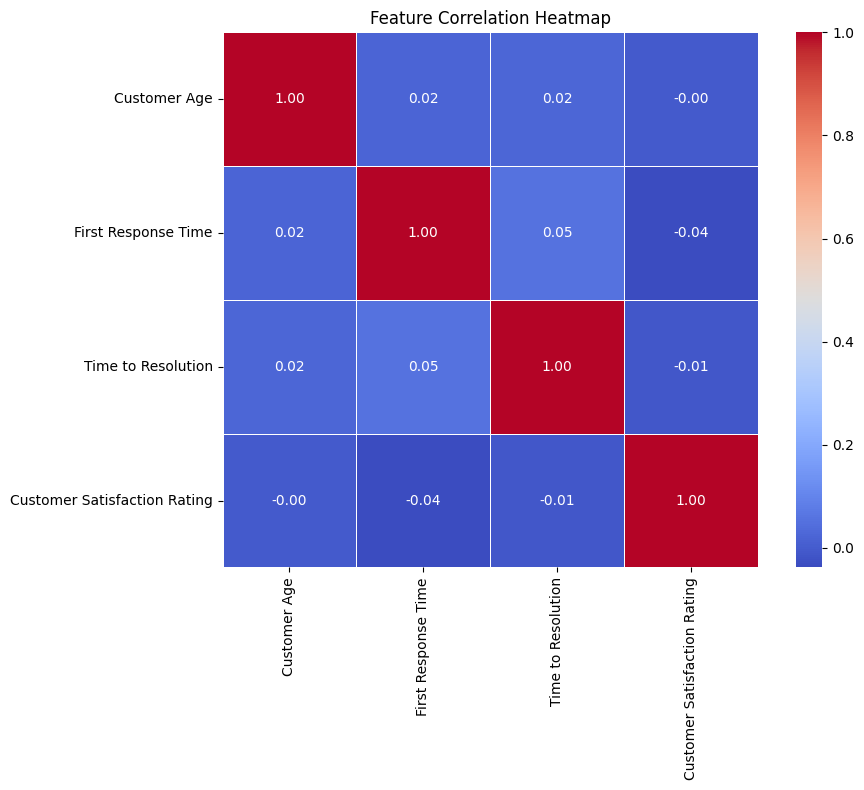

In [81]:
#Correlation HeatMap

numeric_data=data.select_dtypes(include=['number'])
numeric_data=numeric_data.drop(columns=['Ticket ID'],errors='ignore')
corr_matrix=numeric_data.corr()

corr=data[['Customer Age','First Response Time','Time to Resolution','Customer Satisfaction Rating']].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f',square=True,linewidth=0.5)

plt.title("Feature Correlation Heatmap")

plt.tight_layout()
plt.show()

**Observation :**


The Correlation heatmap shows that there are no strong linear Relationships between the numerical variables and customer Satisfcation rating.This suggests that customer satisfcation may depend more on categorical factors such as ticket type ,priority,channel or product purchased,rather than numerical variables like age or response time.